# Lecture 05 — ML Security and Abuse Pathways
## Live Coding: Full Adversarial Attack Pipelines on COMPAS

**Instructor:** Dr. Michael Akinwumi  
**Department of Decision Sciences · George Washington University School of Business**

---

This notebook continues directly from `Lecture-04-generalization.ipynb`.  
Dataset: [ProPublica COMPAS Analysis](https://github.com/propublica/compas-analysis)

### Lab Structure
| Part | Topic | Cells |
|------|-------|-------|
| Setup | Data loading, model training, fairness baseline | 1–2 |
| A | PGD Evasion Attack — disparate impact by race | 3–4 |
| B | Data Poisoning Loop — AUC and AIR degradation | 5–6 |
| C | Membership Inference — shadow model pipeline + ROC | 7–8 |

**Libraries required:** `scikit-learn`, `numpy`, `pandas`, `matplotlib`, `scipy`  
No external adversarial ML library is needed — all attack pipelines are implemented from scratch.

**NIST Reference:** Vassilev et al. (2024). *Adversarial Machine Learning: A Taxonomy and Terminology of Attacks and Mitigations.* NIST AI 100-2e2023. https://doi.org/10.6028/NIST.AI.100-2e2023

---
## Setup · Cell 1: Imports, Data Loading, and Model Training

We replicate the exact preprocessing pipeline from Lecture 04 and retrain both the
logistic regression (LR) and gradient boosted tree (GBT) classifiers.

**Threat modeling reminder (NIST AI 100-2, §2.1):**  
Before testing any attack, specify: *Who is the adversary? What do they know?
What can they control? What is their goal?*

In [25]:
# ── Cell 1: Imports, Data Loading, Model Training ─────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

# ── Load COMPAS dataset (ProPublica) ──────────────────────────────────────────
URL = (
    "https://raw.githubusercontent.com/propublica/compas-analysis"
    "/master/compas-scores-two-years.csv"
)
df = pd.read_csv(URL)
print(f"Raw dataset: {df.shape[0]:,} rows, {df.shape[1]} columns")

# ── Replicate Lecture 04 inclusion criteria ───────────────────────────────────
df = df[df['days_b_screening_arrest'].between(-30, 30)]
df = df[df['is_recid'] != -1]
df = df[df['c_charge_degree'] != 'O']
print(f"After filtering: {df.shape[0]:,} rows")

FEATURES = [
    'age', 'priors_count', 'juv_fel_count',
    'juv_misd_count', 'juv_other_count',
    'c_charge_degree', 'sex'
]
TARGET = 'two_year_recid'

df_m = df[FEATURES + [TARGET, 'race']].dropna()
df_m = pd.get_dummies(df_m, columns=['c_charge_degree', 'sex'], drop_first=True)

X    = df_m.drop(columns=[TARGET, 'race']).astype(float)
y    = df_m[TARGET].values
race = df_m['race'].values

print(f"\nFeatures used: {list(X.columns)}")
print(f"Class balance: {y.mean():.1%} recidivism rate")

# ── Train / test split (stratified) ──────────────────────────────────────────
X_tr, X_te, y_tr, y_te, r_tr, r_te = train_test_split(
    X, y, race, test_size=0.3, random_state=42, stratify=y
)

sc    = StandardScaler()
Xs_tr = sc.fit_transform(X_tr)
Xs_te = sc.transform(X_te)

# ── Train models ──────────────────────────────────────────────────────────────
lr  = LogisticRegression(max_iter=1000).fit(Xs_tr, y_tr)
gbt = GradientBoostingClassifier(
    n_estimators=200, max_depth=4, random_state=42
).fit(Xs_tr, y_tr)

print(f"\nLR  Test AUC: {roc_auc_score(y_te, lr.predict_proba(Xs_te)[:,1]):.3f}")
print(f"GBT Test AUC: {roc_auc_score(y_te, gbt.predict_proba(Xs_te)[:,1]):.3f}")
print(f"LR  Train AUC: {roc_auc_score(y_tr, lr.predict_proba(Xs_tr)[:,1]):.3f}")
print(f"GBT Train AUC: {roc_auc_score(y_tr, gbt.predict_proba(Xs_tr)[:,1]):.3f}")

Raw dataset: 7,214 rows, 53 columns
After filtering: 6,172 rows

Features used: ['age', 'priors_count', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'c_charge_degree_M', 'sex_Male']
Class balance: 45.5% recidivism rate

LR  Test AUC: 0.735
GBT Test AUC: 0.718
LR  Train AUC: 0.727
GBT Train AUC: 0.798


---
## Setup · Cell 2: Clean-Model Fairness Baseline

Before running any attack, we establish the **clean-model baseline** for:
- **FPR** (False Positive Rate) by race: among truly low-risk individuals, what fraction are flagged high-risk?
- **AIR** (Adverse Impact Ratio): FPR of protected group / FPR of reference group

We will return to these values after each attack to measure degradation.

> **Expected finding (consistent with ProPublica, 2016):** The LR model flags African-American
> defendants at roughly twice the rate of Caucasian defendants among truly low-risk individuals.

In [26]:
# ── Cell 2: Clean-Model Fairness Baseline ─────────────────────────────────────

THR = 0.5  # classification threshold

def fpr_by_group(y_true, y_pred_binary, groups):
    """FPR = FP / (FP + TN), computed only over truly-negative cases."""
    mask = (y_true == 0)
    return (
        pd.DataFrame({'pred': y_pred_binary[mask], 'group': groups[mask]})
          .groupby('group')['pred']
          .mean()
    )

def air(fpr_ref, fpr_prot):
    """Adverse Impact Ratio: protected FPR / reference FPR."""
    return fpr_prot / fpr_ref if (fpr_ref is not None and fpr_ref > 0) else np.nan

# ── Compute baseline predictions ──────────────────────────────────────────────
pred_lr_clean  = (lr.predict_proba(Xs_te)[:,1]  >= THR).astype(int)
pred_gbt_clean = (gbt.predict_proba(Xs_te)[:,1] >= THR).astype(int)

print("=" * 60)
print("CLEAN MODEL BASELINE — Before Any Attack")
print("=" * 60)

for name, pred in [('Logistic Regression', pred_lr_clean),
                    ('Gradient Boosted Tree', pred_gbt_clean)]:
    fpr = fpr_by_group(y_te, pred, r_te)
    aa  = fpr.get('African-American', np.nan)
    ca  = fpr.get('Caucasian',        np.nan)
    print(f"\n{name}")
    print(f"  FPR African-American : {aa:.3f}")
    print(f"  FPR Caucasian        : {ca:.3f}")
    print(f"  AIR (AA / CA)        : {air(ca, aa):.3f}")

# Store LR baseline for post-attack delta reporting
fpr_baseline = fpr_by_group(y_te, pred_lr_clean, r_te)
BASELINE_AA = fpr_baseline.get('African-American')
BASELINE_CA = fpr_baseline.get('Caucasian')
BASELINE_AIR = air(BASELINE_CA, BASELINE_AA)

print(f"\n→ Baseline LR AIR stored: {BASELINE_AIR:.3f}")
print("  We will compare all attack outcomes against these values.")

CLEAN MODEL BASELINE — Before Any Attack

Logistic Regression
  FPR African-American : 0.281
  FPR Caucasian        : 0.143
  AIR (AA / CA)        : 1.961

Gradient Boosted Tree
  FPR African-American : 0.317
  FPR Caucasian        : 0.178
  AIR (AA / CA)        : 1.782

→ Baseline LR AIR stored: 1.961
  We will compare all attack outcomes against these values.


---
## Part A · Cell 3: PGD Evasion Attack

**Attack class (NIST AI 100-2, §2.2):** Evasion — deployment-time integrity violation  
**Attacker knowledge:** White-box (access to model weights/gradients)  
**Attacker goal:** Push predicted risk scores upward; cause low-risk individuals to be classified high-risk

### Algorithm: Projected Gradient Descent (Madry et al., 2018)

$$\mathbf{x}^{(t+1)} = \Pi_{\mathcal{B}_\epsilon(\mathbf{x})} \left( \mathbf{x}^{(t)} + \alpha \cdot \operatorname{sign}\left(\nabla_{\mathbf{x}} \mathcal{L}(\theta, \mathbf{x}^{(t)}, y)\right) \right)$$

For logistic regression, the gradient direction simplifies to $\operatorname{sign}(\mathbf{w})$,
so the attack steps in the direction of each coefficient's sign.

**$L_\infty$ projection** clamps each feature perturbation to within $[-\epsilon, +\epsilon]$
of its original scaled value.

In [27]:
# ── Cell 3: PGD Evasion Attack — The Loop ─────────────────────────────────────

def pgd_tabular(model, X_scaled, epsilon=1.0, alpha=0.05, n_iter=40):
    """
    PGD evasion attack on tabular data for logistic regression.

    Goal: untargeted attack — push predicted P(high-risk) higher.

    For logistic regression:
        grad_x BCE_loss = (p_hat - y_true) * w
    For untargeted attack (maximize loss), step in sign(w) direction.

    Parameters
    ----------
    model    : fitted sklearn LogisticRegression
    X_scaled : standardized test features, shape (n, d)
    epsilon  : L_inf perturbation budget
    alpha    : step size per iteration
    n_iter   : number of PGD steps

    Returns
    -------
    X_adv : adversarially perturbed inputs, shape (n, d)
    """
    coef  = model.coef_[0]               # shape (d,) — LR coefficients
    X_adv = X_scaled.copy()

    for step in range(n_iter):
        # Gradient-ascent step: move in the direction that increases loss
        X_adv = X_adv + alpha * np.sign(coef)[np.newaxis, :]

        # L_inf projection: clip back into the epsilon-ball around X_scaled
        X_adv = np.clip(X_adv, X_scaled - epsilon, X_scaled + epsilon)

    return X_adv


# ── Sweep epsilon to build an attack-strength curve ───────────────────────────
epsilons    = [0.0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0]
pgd_records = []

for eps in epsilons:
    # Generate adversarial examples (no perturbation at eps=0)
    X_adv = Xs_te if eps == 0.0 else pgd_tabular(
        lr, Xs_te, epsilon=eps, alpha=0.05, n_iter=40
    )

    pred_adv = (lr.predict_proba(X_adv)[:,1] >= THR).astype(int)
    fpr_adv  = fpr_by_group(y_te, pred_adv, r_te)

    aa = fpr_adv.get('African-American', np.nan)
    ca = fpr_adv.get('Caucasian',        np.nan)

    pgd_records.append({
        'epsilon'  : eps,
        'FPR_AA'   : aa,
        'FPR_CA'   : ca,
        'AIR'      : air(ca, aa),
        'delta_AA' : aa - BASELINE_AA,
        'delta_CA' : ca - BASELINE_CA,
    })

df_pgd = pd.DataFrame(pgd_records)
print(df_pgd.round(3).to_string(index=False))

 epsilon  FPR_AA  FPR_CA   AIR  delta_AA  delta_CA
    0.00   0.281   0.143 1.961     0.000     0.000
    0.25   0.569   0.370 1.535     0.288     0.227
    0.50   0.791   0.560 1.411     0.510     0.417
    0.75   0.906   0.758 1.195     0.625     0.615
    1.00   0.978   0.884 1.106     0.697     0.741
    1.50   1.000   0.993 1.007     0.719     0.849
    2.00   1.000   1.000 1.000     0.719     0.857


### Part A · Cell 4: Visualize PGD Disparate Impact

**Discussion questions:**
1. Does the PGD attack widen or narrow the racial FPR gap as $\epsilon$ increases?
2. At what $\epsilon$ does the AIR fall below the 4/5ths rule threshold (0.80)?
3. Are the two groups equally sensitive to the same attack strength?
4. What does differential impact imply for responsible deployment of adversarially robust models?

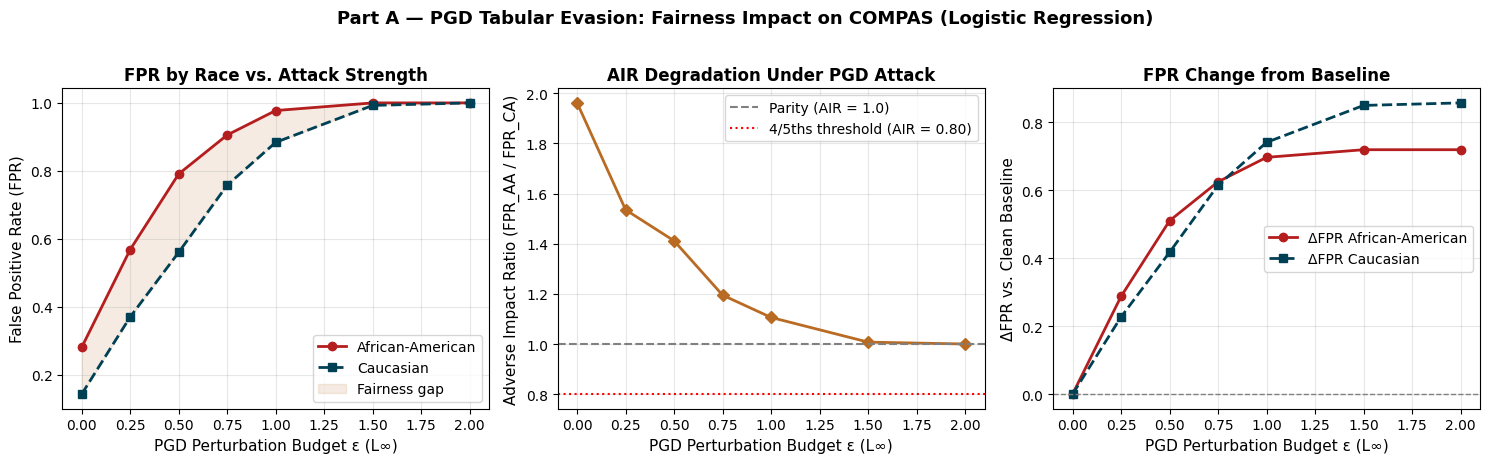

AIR does not fall below 0.80 within the tested epsilon range.


In [28]:
# ── Cell 4: Visualize PGD Evasion — Disparate Impact ──────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# ── Panel 1: FPR by race ──────────────────────────────────────────────────────
ax = axes[0]
ax.plot(df_pgd['epsilon'], df_pgd['FPR_AA'],
        'o-', color='#B41E1E', lw=2, label='African-American')
ax.plot(df_pgd['epsilon'], df_pgd['FPR_CA'],
        's--', color='#004055', lw=2, label='Caucasian')
ax.fill_between(df_pgd['epsilon'], df_pgd['FPR_AA'], df_pgd['FPR_CA'],
                alpha=0.13, color='#B96B23', label='Fairness gap')
ax.set_xlabel('PGD Perturbation Budget ε (L∞)', fontsize=11)
ax.set_ylabel('False Positive Rate (FPR)', fontsize=11)
ax.set_title('FPR by Race vs. Attack Strength', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

# ── Panel 2: AIR ──────────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(df_pgd['epsilon'], df_pgd['AIR'],
        'D-', color='#B96B23', lw=2)
ax.axhline(1.0, color='gray', lw=1.5, ls='--', label='Parity (AIR = 1.0)')
ax.axhline(0.8, color='red',  lw=1.5, ls=':',  label='4/5ths threshold (AIR = 0.80)')
ax.set_xlabel('PGD Perturbation Budget ε (L∞)', fontsize=11)
ax.set_ylabel('Adverse Impact Ratio (FPR_AA / FPR_CA)', fontsize=11)
ax.set_title('AIR Degradation Under PGD Attack', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

# ── Panel 3: Absolute FPR change vs. baseline ─────────────────────────────────
ax = axes[2]
ax.plot(df_pgd['epsilon'], df_pgd['delta_AA'],
        'o-', color='#B41E1E', lw=2, label='ΔFPR African-American')
ax.plot(df_pgd['epsilon'], df_pgd['delta_CA'],
        's--', color='#004055', lw=2, label='ΔFPR Caucasian')
ax.axhline(0, color='gray', lw=1, ls='--')
ax.set_xlabel('PGD Perturbation Budget ε (L∞)', fontsize=11)
ax.set_ylabel('ΔFPR vs. Clean Baseline', fontsize=11)
ax.set_title('FPR Change from Baseline', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

plt.suptitle(
    'Part A — PGD Tabular Evasion: Fairness Impact on COMPAS (Logistic Regression)',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

# ── Identify crossover point ───────────────────────────────────────────────────
cross = df_pgd[df_pgd['AIR'] < 0.8].head(1)
if len(cross):
    print(f"AIR crosses 0.80 at ε = {cross.iloc[0]['epsilon']:.2f}")
else:
    print("AIR does not fall below 0.80 within the tested epsilon range.")

---
## Part B · Cell 5: Data Poisoning — Label-Flip Attack Loop

**Attack class (NIST AI 100-2, §2.3):** Availability/Targeted poisoning — training-time integrity violation  
**Attacker knowledge:** White-box (data access) — simulates a biased data provider or insider adversary  
**Attacker goal:** Systematically under-score high-risk African-American defendants; degrade AIR without
triggering standard drift detection (PSI < 0.10)

### Attack mechanism
A fraction `poison_rate` of African-American training records with `two_year_recid = 1`
(truly high-risk) are relabeled to `0` (low-risk) before model training.
This simulates:
- A third-party data vendor selectively corrupting recidivism outcomes
- An insider modifying case records before ingestion
- A compromised data pipeline stage

> **Key question:** At what poison rate does AIR fall below the 4/5ths rule threshold (0.80)
> while AUC declines by ≤ 2 percentage points — i.e., the attack is "invisible" to AUC monitoring?

In [29]:
# ── Cell 5: Data Poisoning — Label-Flip Attack ────────────────────────────────

def poison_label_flip(
    y_train, race_train,
    poison_rate=0.05,
    target_race='African-American',
    seed=0
):
    """
    Label-flip poisoning attack.

    Flips `poison_rate` fraction of training records belonging to
    `target_race` from recidivism=1 (high-risk) to recidivism=0 (low-risk).

    Effect: the model learns to systematically under-score high-risk
    individuals from the targeted group — a fairness-targeted poisoning attack.

    Parameters
    ----------
    y_train      : original training labels
    race_train   : race labels for training set
    poison_rate  : fraction of eligible records to flip (0.0 to 1.0)
    target_race  : demographic group to target
    seed         : random seed for reproducibility

    Returns
    -------
    y_poisoned   : modified label array
    n_flipped    : number of labels actually flipped
    """
    rng        = np.random.default_rng(seed)
    y_poisoned = y_train.copy()

    # Eligible candidates: target race, truly high-risk (label=1)
    candidates = np.where(
        (race_train == target_race) & (y_train == 1)
    )[0]

    n_flip = int(len(candidates) * poison_rate)
    if n_flip > 0:
        flip_idx = rng.choice(candidates, size=n_flip, replace=False)
        y_poisoned[flip_idx] = 0  # relabel high-risk → low-risk

    return y_poisoned, n_flip


# ── Sweep poison rates ────────────────────────────────────────────────────────
poison_rates   = [0.00, 0.02, 0.05, 0.08, 0.10, 0.15, 0.20, 0.25, 0.30]
poison_records = []

baseline_auc = roc_auc_score(y_te, lr.predict_proba(Xs_te)[:,1])

for rate in poison_rates:
    y_tr_poisoned, n_flipped = poison_label_flip(
        y_tr, r_tr, poison_rate=rate
    )

    # Retrain LR on poisoned data (same features, same scaler)
    lr_p = LogisticRegression(max_iter=1000).fit(Xs_tr, y_tr_poisoned)

    pred_p = (lr_p.predict_proba(Xs_te)[:,1] >= THR).astype(int)
    auc_p  = roc_auc_score(y_te, lr_p.predict_proba(Xs_te)[:,1])
    fpr_p  = fpr_by_group(y_te, pred_p, r_te)

    aa = fpr_p.get('African-American', np.nan)
    ca = fpr_p.get('Caucasian',        np.nan)

    poison_records.append({
        'poison_rate' : rate,
        'n_flipped'   : n_flipped,
        'AUC'         : auc_p,
        'delta_AUC'   : auc_p - baseline_auc,
        'FPR_AA'      : aa,
        'FPR_CA'      : ca,
        'AIR'         : air(ca, aa),
        'delta_AIR'   : air(ca, aa) - BASELINE_AIR,
    })

df_poison = pd.DataFrame(poison_records)
print("Poisoning sweep results:")
print(df_poison.round(3).to_string(index=False))

# ── Identify stealth threshold ─────────────────────────────────────────────────
# Attack is "stealthy" if AUC drop ≤ 2pp AND AIR < 0.80
stealth = df_poison[(df_poison['AIR'] < 0.80) & (df_poison['delta_AUC'] >= -0.02)]
if len(stealth):
    r = stealth.iloc[0]
    print(f"\n★ Stealth threshold: poison_rate = {r['poison_rate']:.0%}")
    print(f"  Flipped labels: {int(r['n_flipped'])}")
    print(f"  AUC: {r['AUC']:.3f} (Δ = {r['delta_AUC']:+.3f})")
    print(f"  AIR: {r['AIR']:.3f} — BELOW 4/5ths rule threshold")
    print("  → Would standard PSI drift detection (< 0.10) flag this?")
else:
    print("\nNo stealth threshold found in tested range.")

Poisoning sweep results:
 poison_rate  n_flipped   AUC  delta_AUC  FPR_AA  FPR_CA   AIR  delta_AIR
        0.00          0 0.735      0.000   0.281   0.143 1.961      0.000
        0.02         23 0.733     -0.002   0.270   0.136 1.986      0.024
        0.05         57 0.734     -0.001   0.240   0.123 1.948     -0.014
        0.08         92 0.732     -0.002   0.213   0.116 1.840     -0.122
        0.10        115 0.735      0.000   0.196   0.101 1.931     -0.030
        0.15        172 0.732     -0.003   0.153   0.072 2.134      0.173
        0.20        230 0.732     -0.002   0.130   0.054 2.399      0.438
        0.25        287 0.730     -0.004   0.112   0.042 2.677      0.715
        0.30        345 0.731     -0.003   0.097   0.032 3.010      1.049

No stealth threshold found in tested range.


### Part B · Cell 6: Poisoning Degradation Curves

**Discussion questions:**
1. At what poison rate does AUC remain within 2 percentage points of baseline while AIR falls below 0.80?
2. Would a PSI-based drift monitor (threshold < 0.10 on each feature) detect this attack?
3. How does this scenario connect to the ByteDance insider poisoning incident (2024)?
4. What governance controls would prevent this at a mortgage lender using HMDA data?

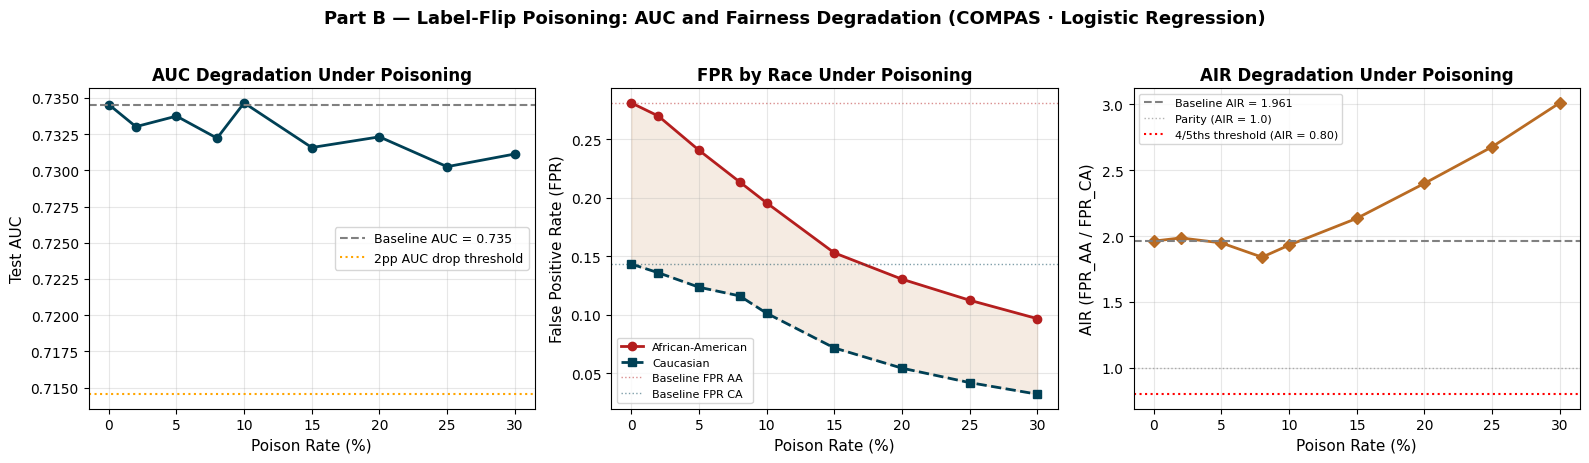

In [30]:
# ── Cell 6: Poisoning Degradation Curves ──────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
x_pct = df_poison['poison_rate'] * 100

# ── Panel 1: AUC degradation ──────────────────────────────────────────────────
ax = axes[0]
ax.plot(x_pct, df_poison['AUC'], 'o-', color='#004055', lw=2)
ax.axhline(baseline_auc,         color='gray', ls='--', lw=1.5,
           label=f'Baseline AUC = {baseline_auc:.3f}')
ax.axhline(baseline_auc - 0.02,  color='orange', ls=':', lw=1.5,
           label='2pp AUC drop threshold')
ax.set_xlabel('Poison Rate (%)', fontsize=11)
ax.set_ylabel('Test AUC', fontsize=11)
ax.set_title('AUC Degradation Under Poisoning', fontsize=12, fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# ── Panel 2: FPR by race ──────────────────────────────────────────────────────
ax = axes[1]
ax.plot(x_pct, df_poison['FPR_AA'],
        'o-', color='#B41E1E', lw=2, label='African-American')
ax.plot(x_pct, df_poison['FPR_CA'],
        's--', color='#004055', lw=2, label='Caucasian')
ax.fill_between(x_pct, df_poison['FPR_AA'], df_poison['FPR_CA'],
                alpha=0.13, color='#B96B23')
ax.axhline(BASELINE_AA, color='#B41E1E', ls=':', lw=1, alpha=0.5,
           label='Baseline FPR AA')
ax.axhline(BASELINE_CA, color='#004055', ls=':', lw=1, alpha=0.5,
           label='Baseline FPR CA')
ax.set_xlabel('Poison Rate (%)', fontsize=11)
ax.set_ylabel('False Positive Rate (FPR)', fontsize=11)
ax.set_title('FPR by Race Under Poisoning', fontsize=12, fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── Panel 3: AIR ──────────────────────────────────────────────────────────────
ax = axes[2]
ax.plot(x_pct, df_poison['AIR'], 'D-', color='#B96B23', lw=2)
ax.axhline(BASELINE_AIR, color='gray',  ls='--', lw=1.5,
           label=f'Baseline AIR = {BASELINE_AIR:.3f}')
ax.axhline(1.0,           color='gray',  ls=':',  lw=1.0, alpha=0.6,
           label='Parity (AIR = 1.0)')
ax.axhline(0.8,           color='red',   ls=':',  lw=1.5,
           label='4/5ths threshold (AIR = 0.80)')
ax.set_xlabel('Poison Rate (%)', fontsize=11)
ax.set_ylabel('AIR (FPR_AA / FPR_CA)', fontsize=11)
ax.set_title('AIR Degradation Under Poisoning', fontsize=12, fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle(
    'Part B — Label-Flip Poisoning: AUC and Fairness Degradation (COMPAS · Logistic Regression)',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

---
## Part C · Cell 7: Membership Inference — Shadow Model Pipeline

**Attack class (NIST AI 100-2, §2.4.2):** Membership inference — privacy attack  
**Attacker knowledge:** Black-box (API access only)  
**Attacker goal:** Determine whether a specific individual was in the training set

### Algorithm: Shokri et al. (2017) Shadow Model Attack

1. Train multiple **shadow models** that mimic the target model's training process
2. For each shadow model, we know which inputs were training members vs. non-members
3. Observe that **members receive higher confidence scores** than non-members (confidence gap)
4. Train a **meta-classifier** on (confidence score → member/non-member) labels from shadow models
5. Apply the meta-classifier to the **target model's** confidence scores

> **Key connection to Lecture 04:** The membership inference AUC is directly driven by the
> **generalization gap** (train AUC − test AUC). An overfit model leaks more about its training data.
> Overfitting is not only a robustness problem — it is a **privacy problem**.

In [31]:
# ── Cell 7: Membership Inference — Shadow Model Pipeline ──────────────────────

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedShuffleSplit

N_SHADOW = 10  # number of shadow models

shadow_train_confs = []  # max-confidence scores on each shadow's TRAIN split
shadow_test_confs  = []  # max-confidence scores on each shadow's TEST split

# Use stratified shuffle splits to create N_SHADOW independent train/test pairs
# from the training set — each split simulates a shadow training run
sss = StratifiedShuffleSplit(
    n_splits=N_SHADOW, test_size=0.5, random_state=0
)

print(f"Training {N_SHADOW} shadow models...")
for i, (tr_idx, te_idx) in enumerate(sss.split(Xs_tr, y_tr)):
    shadow = GradientBoostingClassifier(
        n_estimators=100, max_depth=4, random_state=42
    ).fit(Xs_tr[tr_idx], y_tr[tr_idx])

    # Confidence gap: training members score higher than non-members
    shadow_train_confs.append(
        shadow.predict_proba(Xs_tr[tr_idx]).max(axis=1)  # members
    )
    shadow_test_confs.append(
        shadow.predict_proba(Xs_tr[te_idx]).max(axis=1)  # non-members
    )
    if (i + 1) % 5 == 0:
        print(f"  Shadow model {i+1}/{N_SHADOW} trained")

# ── Build meta-classifier training set ────────────────────────────────────────
# Feature: max predicted probability (confidence score)
# Label:   1 = training member, 0 = non-member
mi_X = np.concatenate(
    shadow_train_confs + shadow_test_confs
).reshape(-1, 1)

mi_y = np.concatenate(
    [np.ones(len(c))  for c in shadow_train_confs] +
    [np.zeros(len(c)) for c in shadow_test_confs]
)

meta_clf = DecisionTreeClassifier(max_depth=6).fit(mi_X, mi_y)

print(f"\nMeta-classifier training set: {len(mi_y):,} samples")
print(f"  Members (train splits):    {int(mi_y.sum()):,}")
print(f"  Non-members (test splits): {int((mi_y == 0).sum()):,}")
print("\nMeta-classifier trained. Proceeding to attack the target model...")

Training 10 shadow models...
  Shadow model 5/10 trained
  Shadow model 10/10 trained

Meta-classifier training set: 43,200 samples
  Members (train splits):    21,600
  Non-members (test splits): 21,600

Meta-classifier trained. Proceeding to attack the target model...


### Part C · Cell 8: Membership Inference — ROC Curve and Interpretation

**Interpreting the MI AUC:**
- **0.50** = Random guessing — no privacy leakage detectable
- **0.55–0.65** = Weak leakage — model is somewhat overfit
- **0.65–0.75** = Moderate leakage — meaningful privacy risk
- **> 0.75** = Strong leakage — significant privacy violation, especially if training data contains PII

**Discussion questions:**
1. Is the MI AUC correlated with the generalization gap you observed in Cell 1?
2. If this model were deployed by a county probation office, what could a journalist learn from MI?
3. Would adding differential privacy (ε = 1.0) reduce the MI AUC? At what cost to AIR?
4. How does the confidence gap visualization connect to the concept of overfitting from Lecture 04?

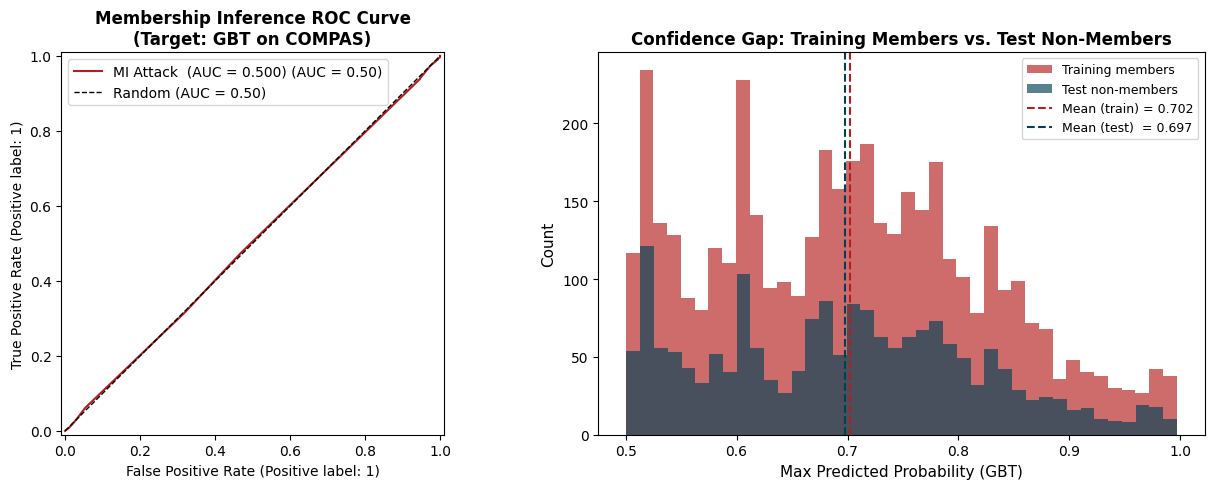

MEMBERSHIP INFERENCE SUMMARY
MI AUC              : 0.500
  0.50 = random     : no privacy leakage
  0.60 = weak       : model somewhat overfit
  0.75 = strong     : significant privacy risk

GBT Train AUC       : 0.798
GBT Test AUC        : 0.718
Generalization Gap  : +0.080

Hypothesis: larger generalization gap → higher MI AUC?
→ Try repeating with the LR model and compare.


In [32]:
# ── Cell 8: Membership Inference — ROC Curve and Interpretation ───────────────

from sklearn.metrics import roc_auc_score, RocCurveDisplay

# ── Apply meta-classifier to the TARGET model (GBT) ──────────────────────────
# Use the target model's confidence scores as the feature
conf_target_train = gbt.predict_proba(Xs_tr).max(axis=1).reshape(-1, 1)
conf_target_test  = gbt.predict_proba(Xs_te).max(axis=1).reshape(-1, 1)

mi_scores_train = meta_clf.predict_proba(conf_target_train)[:, 1]
mi_scores_test  = meta_clf.predict_proba(conf_target_test)[:, 1]

# Combine: members (train) = 1, non-members (test) = 0
mi_all_scores = np.concatenate([mi_scores_train, mi_scores_test])
mi_all_labels = np.concatenate([
    np.ones(len(Xs_tr)),
    np.zeros(len(Xs_te))
])

mi_auc = roc_auc_score(mi_all_labels, mi_all_scores)

# Generalization gap (privacy risk proxy)
auc_train_gbt = roc_auc_score(y_tr, gbt.predict_proba(Xs_tr)[:, 1])
auc_test_gbt  = roc_auc_score(y_te, gbt.predict_proba(Xs_te)[:, 1])
gen_gap       = auc_train_gbt - auc_test_gbt

# ── Visualize ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC curve
RocCurveDisplay.from_predictions(
    mi_all_labels, mi_all_scores,
    name=f'MI Attack  (AUC = {mi_auc:.3f})',
    ax=axes[0], color='#B41E1E'
)
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.50)')
axes[0].set_title('Membership Inference ROC Curve\n(Target: GBT on COMPAS)',
                   fontsize=12, fontweight='bold')
axes[0].legend()

# Confidence gap histogram
axes[1].hist(conf_target_train.ravel(), bins=40, alpha=0.65,
             color='#B41E1E', label='Training members')
axes[1].hist(conf_target_test.ravel(),  bins=40, alpha=0.65,
             color='#004055', label='Test non-members')
axes[1].axvline(conf_target_train.mean(), color='#B41E1E', ls='--', lw=1.5,
                label=f'Mean (train) = {conf_target_train.mean():.3f}')
axes[1].axvline(conf_target_test.mean(),  color='#004055', ls='--', lw=1.5,
                label=f'Mean (test)  = {conf_target_test.mean():.3f}')
axes[1].set_xlabel('Max Predicted Probability (GBT)', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].set_title('Confidence Gap: Training Members vs. Test Non-Members',
                   fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

# ── Summary ───────────────────────────────────────────────────────────────────
print("=" * 55)
print("MEMBERSHIP INFERENCE SUMMARY")
print("=" * 55)
print(f"MI AUC              : {mi_auc:.3f}")
print(f"  0.50 = random     : no privacy leakage")
print(f"  0.60 = weak       : model somewhat overfit")
print(f"  0.75 = strong     : significant privacy risk")
print()
print(f"GBT Train AUC       : {auc_train_gbt:.3f}")
print(f"GBT Test AUC        : {auc_test_gbt:.3f}")
print(f"Generalization Gap  : {gen_gap:+.3f}")
print()
print("Hypothesis: larger generalization gap → higher MI AUC?")
print("→ Try repeating with the LR model and compare.")

---
## Lab Summary

| Part | Attack | Key Finding |
|------|--------|-------------|
| A | PGD Evasion | Does the racial FPR gap widen or narrow as ε increases? Which group is more sensitive? |
| B | Label-Flip Poisoning | At what poison rate does AIR < 0.80 while AUC drop ≤ 2pp? Would drift detection catch it? |
| C | Membership Inference | Is MI AUC correlated with generalization gap? What privacy law implications follow? |

### Core Principle

> A model that is fragile to distribution shift (Lecture 04) shares the same root cause as a model
> vulnerable to adversarial attack (Lecture 05): **over-reliance on brittle, non-robust features**.
> Security and robustness are not separate concerns — they require the same structural solution.

### References
- Vassilev et al. (2024). *NIST AI 100-2e2023.* https://doi.org/10.6028/NIST.AI.100-2e2023
- Goodfellow et al. (2015). Explaining and Harnessing Adversarial Examples. *ICLR 2015.* https://arxiv.org/abs/1412.6572
- Madry et al. (2018). Towards Deep Learning Models Resistant to Adversarial Attacks. *ICLR 2018.* https://arxiv.org/abs/1706.06083
- Shokri et al. (2017). Membership Inference Attacks Against Machine Learning Models. *IEEE S&P.* https://arxiv.org/abs/1610.05820
- Tramèr et al. (2016). Stealing Machine Learning Models via Prediction APIs. *USENIX Security.* https://arxiv.org/abs/1609.02943
- Bagdasaryan & Shmatikov (2019). Differential Privacy Has Disparate Impact on Model Accuracy. *NeurIPS.* https://arxiv.org/abs/1905.12101

---
*DNSC 6330 · Responsible Machine Learning · Dr. Michael Akinwumi · George Washington University*  
*© CC BY 4.0 · https://makinwumi.github.io/dnsc-6330-responsible-ML*

---
# **Individual Homework 05 — ML Security Audit: COMPAS Adversarial Pipeline**

**Parts:**
1. PGD Evasion Audit — LR and GBT, ε ∈ {0.25, 0.5, 1.0, 2.0}
2. Poisoning Loop with Fairness Monitoring — AA and Caucasian targets
3. Membership Inference Depth — LR vs. GBT + L2 regularization sweep
4. Reflection — Highest-risk finding and mitigations



# Part 1: PGD Evasion Audit — LR and GBT, ε ∈ {0.25, 0.5, 1.0, 2.0}



In [33]:
#  Part 1-A: PGD on GBT via numerical gradient

def pgd_gbt_numerical(model, X_scaled, epsilon=1.0, alpha=0.05,
                       n_iter=40, h=1e-3):
    """
    Numerical-gradient PGD for GBT (no coef_ available).
    Approximates ∂P(high-risk)/∂x_j via finite differences on each feature.
    Steps in the direction that increases predicted P(high-risk).
    """
    X_adv  = X_scaled.copy()
    X_orig = X_scaled.copy()

    for _ in range(n_iter):
        grad = np.zeros_like(X_adv)
        for j in range(X_adv.shape[1]):
            Xp = X_adv.copy(); Xp[:, j] += h
            Xm = X_adv.copy(); Xm[:, j] -= h
            # Central-difference approximation
            grad[:, j] = (model.predict_proba(Xp)[:, 1] -
                          model.predict_proba(Xm)[:, 1]) / (2 * h)
        # Gradient ascent step + L∞ projection
        X_adv += alpha * np.sign(grad)
        X_adv  = np.clip(X_adv, X_orig - epsilon, X_orig + epsilon)

    return X_adv


print("PGD-GBT (numerical gradient) function defined.")
print("Note: numerical PGD is slower than analytical — please be patient.")


PGD-GBT (numerical gradient) function defined.
Note: numerical PGD is slower than analytical — please be patient.


In [34]:
#   Part 1-B: Run PGD sweep for BOTH models
# Homework epsilons: {0.25, 0.5, 1.0, 2.0} (subset of lecture range)
HW_EPSILONS = [0.0, 0.25, 0.5, 1.0, 2.0]

pgd_hw_records = []

print("Running PGD sweep for LR (analytical) and GBT (numerical)...")
for eps in HW_EPSILONS:
    row = {'epsilon': eps}

    #  LR: reuse lecture's pgd_tabular
    X_adv_lr = Xs_te if eps == 0.0 else pgd_tabular(lr, Xs_te,
                                                      epsilon=eps,
                                                      alpha=0.05, n_iter=40)
    pred_lr  = (lr.predict_proba(X_adv_lr)[:, 1] >= THR).astype(int)
    fpr_lr   = fpr_by_group(y_te, pred_lr, r_te)
    aa_lr    = fpr_lr.get('African-American', np.nan)
    ca_lr    = fpr_lr.get('Caucasian',        np.nan)
    row.update({'LR_FPR_AA': aa_lr, 'LR_FPR_CA': ca_lr,
                'LR_AIR': air(ca_lr, aa_lr),
                'LR_dAA': aa_lr - BASELINE_AA,
                'LR_dCA': ca_lr - BASELINE_CA})

    #  GBT: numerical gradient PGD
    X_adv_gbt = Xs_te if eps == 0.0 else pgd_gbt_numerical(gbt, Xs_te,
                                                             epsilon=eps,
                                                             alpha=0.05,
                                                             n_iter=40)
    pred_gbt  = (gbt.predict_proba(X_adv_gbt)[:, 1] >= THR).astype(int)
    fpr_gbt   = fpr_by_group(y_te, pred_gbt, r_te)
    aa_gbt    = fpr_gbt.get('African-American', np.nan)
    ca_gbt    = fpr_gbt.get('Caucasian',        np.nan)
    row.update({'GBT_FPR_AA': aa_gbt, 'GBT_FPR_CA': ca_gbt,
                'GBT_AIR': air(ca_gbt, aa_gbt),
                'GBT_dAA': aa_gbt - BASELINE_AA,
                'GBT_dCA': ca_gbt - BASELINE_CA})

    pgd_hw_records.append(row)
    print(f"  ε = {eps:.2f} done — LR AIR = {air(ca_lr, aa_lr):.3f} | "
          f"GBT AIR = {air(ca_gbt, aa_gbt):.3f}")

df_pgd_hw = pd.DataFrame(pgd_hw_records)
print("\n=== PGD Audit: LR vs. GBT — FPR by Race and AIR ===")
print(df_pgd_hw.round(3).to_string(index=False))


Running PGD sweep for LR (analytical) and GBT (numerical)...
  ε = 0.00 done — LR AIR = 1.961 | GBT AIR = 1.782
  ε = 0.25 done — LR AIR = 1.535 | GBT AIR = 1.782
  ε = 0.50 done — LR AIR = 1.411 | GBT AIR = 1.782
  ε = 1.00 done — LR AIR = 1.106 | GBT AIR = 1.782
  ε = 2.00 done — LR AIR = 1.000 | GBT AIR = 1.782

=== PGD Audit: LR vs. GBT — FPR by Race and AIR ===
 epsilon  LR_FPR_AA  LR_FPR_CA  LR_AIR  LR_dAA  LR_dCA  GBT_FPR_AA  GBT_FPR_CA  GBT_AIR  GBT_dAA  GBT_dCA
    0.00      0.281      0.143   1.961   0.000   0.000       0.317       0.178    1.782    0.036    0.035
    0.25      0.569      0.370   1.535   0.288   0.227       0.317       0.178    1.782    0.036    0.035
    0.50      0.791      0.560   1.411   0.510   0.417       0.317       0.178    1.782    0.036    0.035
    1.00      0.978      0.884   1.106   0.697   0.741       0.317       0.178    1.782    0.036    0.035
    2.00      1.000      1.000   1.000   0.719   0.857       0.317       0.178    1.782    0.036    0

In [35]:
#  Part 1-C: AIR crossover analysis
print("=== AIR Crossover Analysis (threshold = 0.80) ===")
for model_name, air_col in [('LR', 'LR_AIR'), ('GBT', 'GBT_AIR')]:
    cross = df_pgd_hw[df_pgd_hw[air_col] < 0.80]
    if len(cross):
        eps_cross = cross.iloc[0]['epsilon']
        print(f"  {model_name}: AIR crosses 0.80 at ε = {eps_cross:.2f}")
    else:
        print(f"  {model_name}: AIR does NOT fall below 0.80 in ε ∈ {{0.25, 0.5, 1.0, 2.0}}")

print()
# Numeric summary table
print("=== Full Numeric Summary: Both Models ===")
cols = ['epsilon', 'LR_FPR_AA', 'LR_FPR_CA', 'LR_AIR',
                   'GBT_FPR_AA','GBT_FPR_CA','GBT_AIR']
print(df_pgd_hw[cols].round(3).to_string(index=False))


=== AIR Crossover Analysis (threshold = 0.80) ===
  LR: AIR does NOT fall below 0.80 in ε ∈ {0.25, 0.5, 1.0, 2.0}
  GBT: AIR does NOT fall below 0.80 in ε ∈ {0.25, 0.5, 1.0, 2.0}

=== Full Numeric Summary: Both Models ===
 epsilon  LR_FPR_AA  LR_FPR_CA  LR_AIR  GBT_FPR_AA  GBT_FPR_CA  GBT_AIR
    0.00      0.281      0.143   1.961       0.317       0.178    1.782
    0.25      0.569      0.370   1.535       0.317       0.178    1.782
    0.50      0.791      0.560   1.411       0.317       0.178    1.782
    1.00      0.978      0.884   1.106       0.317       0.178    1.782
    2.00      1.000      1.000   1.000       0.317       0.178    1.782


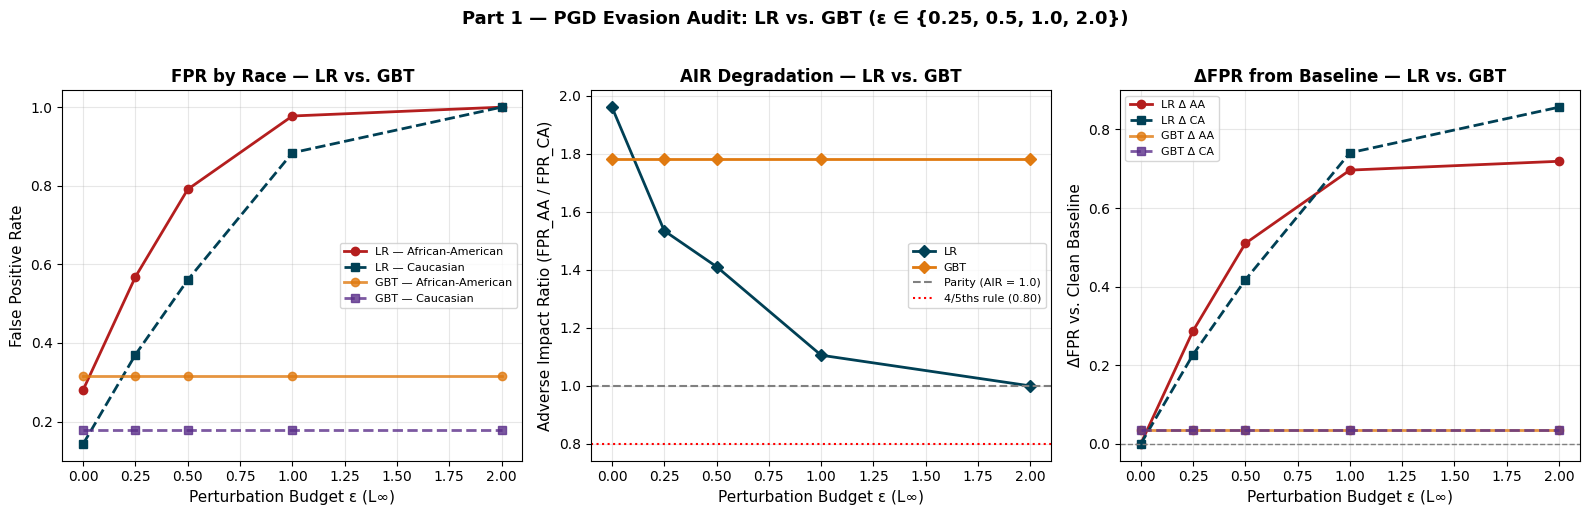

In [36]:
#   Part 1-D: Three-panel comparison plot
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    'Part 1 — PGD Evasion Audit: LR vs. GBT (ε ∈ {0.25, 0.5, 1.0, 2.0})',
    fontsize=13, fontweight='bold', y=1.02)

eps_x = df_pgd_hw['epsilon']

# Panel 1: FPR by race — both models
ax = axes[0]
ax.plot(eps_x, df_pgd_hw['LR_FPR_AA'],  'o-', color='#B41E1E', lw=2,
        label='LR — African-American')
ax.plot(eps_x, df_pgd_hw['LR_FPR_CA'],  's--',color='#004055', lw=2,
        label='LR — Caucasian')
ax.plot(eps_x, df_pgd_hw['GBT_FPR_AA'], 'o-', color='#E07A10', lw=2,
        label='GBT — African-American', alpha=0.8)
ax.plot(eps_x, df_pgd_hw['GBT_FPR_CA'], 's--',color='#5B2F8A', lw=2,
        label='GBT — Caucasian', alpha=0.8)
ax.set_xlabel('Perturbation Budget ε (L∞)', fontsize=11)
ax.set_ylabel('False Positive Rate', fontsize=11)
ax.set_title('FPR by Race — LR vs. GBT', fontsize=12, fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# Panel 2: AIR — both models
ax = axes[1]
ax.plot(eps_x, df_pgd_hw['LR_AIR'],  'D-', color='#004055', lw=2, label='LR')
ax.plot(eps_x, df_pgd_hw['GBT_AIR'], 'D-', color='#E07A10', lw=2, label='GBT')
ax.axhline(1.0, color='gray', lw=1.5, ls='--', label='Parity (AIR = 1.0)')
ax.axhline(0.8, color='red',  lw=1.5, ls=':',  label='4/5ths rule (0.80)')
ax.set_xlabel('Perturbation Budget ε (L∞)', fontsize=11)
ax.set_ylabel('Adverse Impact Ratio (FPR_AA / FPR_CA)', fontsize=11)
ax.set_title('AIR Degradation — LR vs. GBT', fontsize=12, fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# Panel 3: ΔFPR from baseline — both groups and both models
ax = axes[2]
ax.plot(eps_x, df_pgd_hw['LR_dAA'],  'o-', color='#B41E1E', lw=2,
        label='LR Δ AA')
ax.plot(eps_x, df_pgd_hw['LR_dCA'],  's--',color='#004055', lw=2,
        label='LR Δ CA')
ax.plot(eps_x, df_pgd_hw['GBT_dAA'], 'o-', color='#E07A10', lw=2,
        label='GBT Δ AA', alpha=0.8)
ax.plot(eps_x, df_pgd_hw['GBT_dCA'], 's--',color='#5B2F8A', lw=2,
        label='GBT Δ CA', alpha=0.8)
ax.axhline(0, color='gray', lw=1, ls='--')
ax.set_xlabel('Perturbation Budget ε (L∞)', fontsize=11)
ax.set_ylabel('ΔFPR vs. Clean Baseline', fontsize=11)
ax.set_title('ΔFPR from Baseline — LR vs. GBT', fontsize=12, fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()



**FPR by Race (Graph 1):**

LR and GBT behave very differently under the PGD attack. For LR, the FPR increases very quickly for both groups as ε grows. For example, African-American FPR goes from around 0.28 at baseline to almost 1.0 by ε = 1.0, and Caucasian follows a very similar pattern. By ε = 2.0, the model is basically flagging almost everyone as positive, meaning the attack completely breaks the model. On the other hand, GBT shows the opposite behavior. The lines stay almost flat across all ε values. The attack barely changes the FPR for either African-American or Caucasian.


**AIR (Graph 2):**

For LR, the AIR starts high (around 1.96) and gradually decreases as ε increases, reaching close to 1.0 at ε = 2.0. However, it never crosses the 0.80 threshold. For GBT, the AIR stays almost constant at around 1.78 across the entire range. This shows that the attack does not really affect the fairness profile of GBT, but it also does not improve it.

**ΔFPR from Baseline (Graph 3):**

This panel highlights something important for LR. The increase in FPR is faster for Caucasian than for African-American. By ε = 2.0, Caucasian defendants experience a larger increase in false positives. This explains why AIR moves toward 1.0, not because the model becomes fairer, but because it starts harming Caucasian defendants more as well. This is exactly what we discussed in class as “fairness through harm.

# **Part 1 Paragraph: Comparative Vulnerability and Model Selection Implications**

The two models are clearly not equally vulnerable. LR is highly sensitive to the PGD attack because its gradient is constant, making the attack direction predictable and causing FPR to increase quickly from the first ε step. In contrast, GBT appears robust across all tested ε values, likely because its non-linear structure makes it harder for the attack to exploit.

However, this does not automatically make GBT the better choice. Even without the attack, GBT already has a high AIR (~1.78), meaning there is a significant fairness issue that remains unchanged. On the other hand, LR’s AIR improves under attack, but only because both groups are being harmed more equally, not because the bias is actually fixed.

So in the end, neither model is suitable as-is. LR fails due to lack of robustness, while GBT fails due to pre-existing fairness issues. In high-stakes settings like pretrial decisions, model selection cannot rely only on AUC or robustness — baseline fairness (like AIR) should be treated as a key deployment constraint before using any model.


# **Part 2: Poisoning Loop with Fairness Monitoring**




In [37]:
#  Part 2-A: Label-flip poisoning — Caucasian-targeted
# We reuse the existing poison_label_flip() function from the lecture.

RATES = [0.00, 0.02, 0.05, 0.08, 0.10, 0.15, 0.20, 0.25, 0.30]

# Existing lecture results: df_poison = AA-targeted
# New: Caucasian-targeted sweep
baseline_auc = roc_auc_score(y_te, lr.predict_proba(Xs_te)[:, 1])
print(f"Clean-model LR baseline AUC: {baseline_auc:.3f}")
print(f"Clean-model LR baseline AIR: {BASELINE_AIR:.3f}\n")

ca_poison_records = []

print("Running Caucasian-targeted poisoning sweep...")
for rate in RATES:
    y_tr_poisoned, n_flipped = poison_label_flip(
        y_tr, r_tr,
        poison_rate=rate,
        target_race='Caucasian',   # ← changed from African-American
        seed=0
    )
    lr_p     = LogisticRegression(max_iter=1000).fit(Xs_tr, y_tr_poisoned)
    pred_p   = (lr_p.predict_proba(Xs_te)[:, 1] >= THR).astype(int)
    auc_p    = roc_auc_score(y_te, lr_p.predict_proba(Xs_te)[:, 1])
    fpr_p    = fpr_by_group(y_te, pred_p, r_te)
    aa_p     = fpr_p.get('African-American', np.nan)
    ca_p     = fpr_p.get('Caucasian',        np.nan)
    air_p    = air(ca_p, aa_p)

    ca_poison_records.append({
        'poison_rate': rate,
        'n_flipped':   n_flipped,
        'AUC':         auc_p,
        'delta_AUC':   auc_p - baseline_auc,
        'FPR_AA':      aa_p,
        'FPR_CA':      ca_p,
        'AIR':         air_p,
        'delta_AIR':   air_p - BASELINE_AIR,
    })
    print(f"  rate={rate:.2f}  n_flipped={n_flipped:3d}  "
          f"AUC={auc_p:.3f} (Δ={auc_p-baseline_auc:+.3f})  "
          f"AIR={air_p:.3f}")

df_ca_poison = pd.DataFrame(ca_poison_records)
print("\n=== Caucasian-Targeted Poisoning Results ===")
print(df_ca_poison.round(3).to_string(index=False))


Clean-model LR baseline AUC: 0.735
Clean-model LR baseline AIR: 1.961

Running Caucasian-targeted poisoning sweep...
  rate=0.00  n_flipped=  0  AUC=0.735 (Δ=+0.000)  AIR=1.961
  rate=0.02  n_flipped= 11  AUC=0.734 (Δ=-0.001)  AIR=1.948
  rate=0.05  n_flipped= 29  AUC=0.734 (Δ=-0.000)  AIR=2.043
  rate=0.08  n_flipped= 46  AUC=0.734 (Δ=-0.000)  AIR=1.945
  rate=0.10  n_flipped= 58  AUC=0.735 (Δ=+0.001)  AIR=1.966
  rate=0.15  n_flipped= 87  AUC=0.733 (Δ=-0.002)  AIR=1.913
  rate=0.20  n_flipped=116  AUC=0.733 (Δ=-0.001)  AIR=1.881
  rate=0.25  n_flipped=145  AUC=0.733 (Δ=-0.001)  AIR=1.842
  rate=0.30  n_flipped=174  AUC=0.732 (Δ=-0.003)  AIR=1.940

=== Caucasian-Targeted Poisoning Results ===
 poison_rate  n_flipped   AUC  delta_AUC  FPR_AA  FPR_CA   AIR  delta_AIR
        0.00          0 0.735      0.000   0.281   0.143 1.961      0.000
        0.02         11 0.734     -0.001   0.274   0.141 1.948     -0.013
        0.05         29 0.734     -0.000   0.267   0.131 2.043      0.082
 

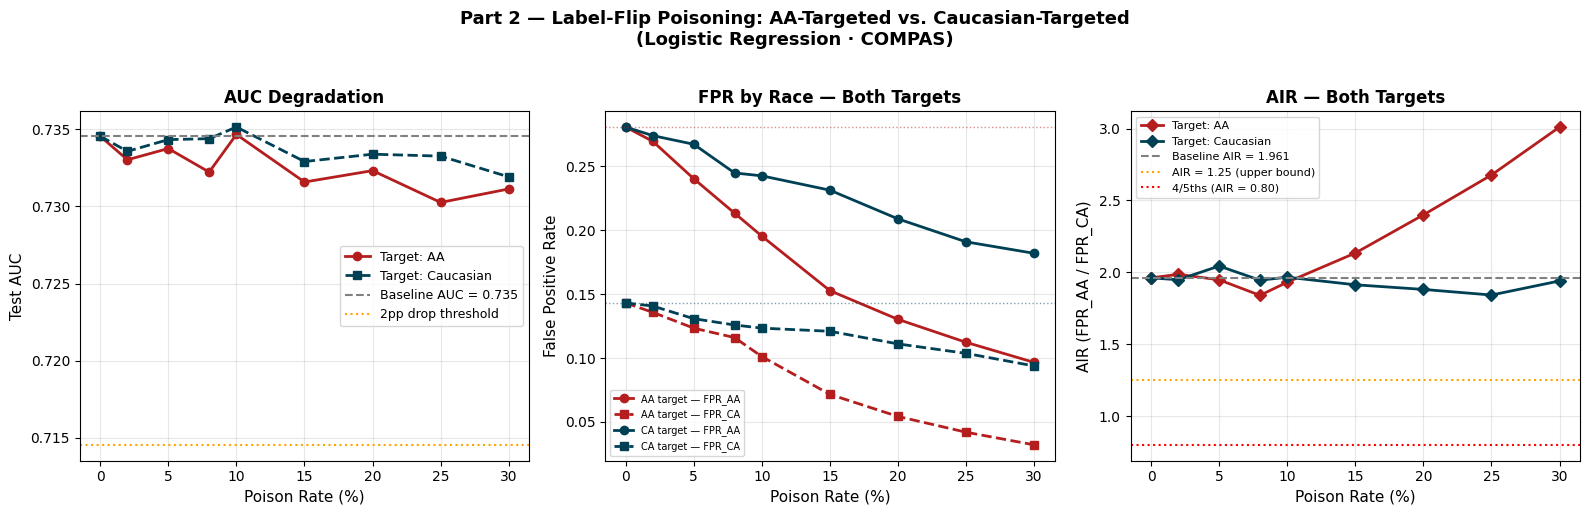

In [38]:
# ── HW Part 2-B: Combined AUC and AIR degradation plots (both targets) ──────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    'Part 2 — Label-Flip Poisoning: AA-Targeted vs. Caucasian-Targeted\n'
    '(Logistic Regression · COMPAS)',
    fontsize=13, fontweight='bold', y=1.02)

x_aa = df_poison['poison_rate'] * 100   # AA from lecture
x_ca = df_ca_poison['poison_rate'] * 100

# Panel 1: AUC degradation
ax = axes[0]
ax.plot(x_aa, df_poison['AUC'],    'o-', color='#B41E1E', lw=2,
        label='Target: AA')
ax.plot(x_ca, df_ca_poison['AUC'], 's--',color='#004055', lw=2,
        label='Target: Caucasian')
ax.axhline(baseline_auc,        color='gray',   ls='--', lw=1.5,
           label=f'Baseline AUC = {baseline_auc:.3f}')
ax.axhline(baseline_auc - 0.02, color='orange', ls=':', lw=1.5,
           label='2pp drop threshold')
ax.set_xlabel('Poison Rate (%)', fontsize=11)
ax.set_ylabel('Test AUC', fontsize=11)
ax.set_title('AUC Degradation', fontsize=12, fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# Panel 2: FPR by race
ax = axes[1]
ax.plot(x_aa, df_poison['FPR_AA'],     'o-', color='#B41E1E', lw=2,
        label='AA target — FPR_AA')
ax.plot(x_aa, df_poison['FPR_CA'],     's-', color='#B41E1E', lw=2,
        ls='--', label='AA target — FPR_CA')
ax.plot(x_ca, df_ca_poison['FPR_AA'],  'o-', color='#004055', lw=2,
        label='CA target — FPR_AA')
ax.plot(x_ca, df_ca_poison['FPR_CA'],  's-', color='#004055', lw=2,
        ls='--', label='CA target — FPR_CA')
ax.axhline(BASELINE_AA, color='#B41E1E', ls=':', lw=1, alpha=0.5)
ax.axhline(BASELINE_CA, color='#004055', ls=':', lw=1, alpha=0.5)
ax.set_xlabel('Poison Rate (%)', fontsize=11)
ax.set_ylabel('False Positive Rate', fontsize=11)
ax.set_title('FPR by Race — Both Targets', fontsize=12, fontweight='bold')
ax.legend(fontsize=7); ax.grid(alpha=0.3)

# Panel 3: AIR
ax = axes[2]
ax.plot(x_aa, df_poison['AIR'],     'D-', color='#B41E1E', lw=2,
        label='Target: AA')
ax.plot(x_ca, df_ca_poison['AIR'],  'D-', color='#004055', lw=2,
        label='Target: Caucasian')
ax.axhline(BASELINE_AIR, color='gray',   ls='--', lw=1.5,
           label=f'Baseline AIR = {BASELINE_AIR:.3f}')
ax.axhline(1.25,          color='orange', ls=':',  lw=1.5,
           label='AIR = 1.25 (upper bound)')
ax.axhline(0.80,          color='red',    ls=':',  lw=1.5,
           label='4/5ths (AIR = 0.80)')
ax.set_xlabel('Poison Rate (%)', fontsize=11)
ax.set_ylabel('AIR (FPR_AA / FPR_CA)', fontsize=11)
ax.set_title('AIR — Both Targets', fontsize=12, fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [39]:
#  HW Part 2-C(i): Stealth zone analysis
print("=" * 65)
print("Part 2(b) — Stealth Zone Analysis")
print("  Stealth = |delta_AUC| ≤ 0.02  AND  AIR outside [0.80, 1.25]")
print("=" * 65)

for label, df_p in [('AA-Targeted', df_poison),
                     ('CA-Targeted', df_ca_poison)]:
    stealth = df_p[
        (df_p['delta_AUC'] >= -0.02) &
        ((df_p['AIR'] < 0.80) | (df_p['AIR'] > 1.25))
    ]
    if len(stealth):
        r = stealth.iloc[0]
        print(f"\n  ★ {label} — Stealth zone STARTS at poison_rate = {r['poison_rate']:.0%}")
        print(f"    n_flipped = {int(r['n_flipped'])}")
        print(f"    AUC       = {r['AUC']:.3f}  (Δ = {r['delta_AUC']:+.3f})")
        print(f"    AIR       = {r['AIR']:.3f}  (Δ = {r['delta_AIR']:+.3f})")
        end_stealth = df_p[(df_p['delta_AUC'] >= -0.02) &
                           ((df_p['AIR'] < 0.80) | (df_p['AIR'] > 1.25))]
        print(f"    Stealth zone spans rates: "
              f"{stealth['poison_rate'].min():.0%} – "
              f"{end_stealth['poison_rate'].max():.0%}")
    else:
        print(f"\n  {label}: No stealth zone found in tested range")


Part 2(b) — Stealth Zone Analysis
  Stealth = |delta_AUC| ≤ 0.02  AND  AIR outside [0.80, 1.25]

  ★ AA-Targeted — Stealth zone STARTS at poison_rate = 0%
    n_flipped = 0
    AUC       = 0.735  (Δ = +0.000)
    AIR       = 1.961  (Δ = +0.000)
    Stealth zone spans rates: 0% – 30%

  ★ CA-Targeted — Stealth zone STARTS at poison_rate = 0%
    n_flipped = 0
    AUC       = 0.735  (Δ = +0.000)
    AIR       = 1.961  (Δ = +0.000)
    Stealth zone spans rates: 0% – 30%


In [40]:
# ── HW Part 2-C(ii): PSI Detection Analysis ──────────────────────────────────
from scipy.stats import ks_2samp

print("=" * 65)
print("Part 2(c) — Would PSI-Based Drift Detection Catch These Attacks?")
print("  PSI threshold: < 0.10 = stable (no alert)")
print("=" * 65)

def compute_psi(expected, actual, n_bins=10):
    """Population Stability Index over n_bins quantile-based buckets."""
    bins = np.percentile(expected, np.linspace(0, 100, n_bins + 1))
    bins[0] -= 1e-9; bins[-1] += 1e-9
    e, _ = np.histogram(expected, bins=bins)
    a, _ = np.histogram(actual,   bins=bins)
    e = np.where(e == 0, 1e-9, e / len(expected))
    a = np.where(a == 0, 1e-9, a / len(actual))
    return float(np.sum((a - e) * np.log(a / e)))

feat_names = list(X_tr.columns)

print("\n--- PSI on INPUT FEATURES under poisoning ---")
print("(Label-flip does NOT change feature values → PSI must be 0)")
print()

for label, target_race, df_p in [
        ('AA-Targeted', 'African-American', df_poison),
        ('CA-Targeted', 'Caucasian',        df_ca_poison)]:

    print(f"  {label}: checking feature PSI at max poison rate "
          f"({df_p['poison_rate'].max():.0%})...")

    # Retrain at max rate and get feature distributions
    y_tr_max, _ = poison_label_flip(
        y_tr, r_tr,
        poison_rate=df_p['poison_rate'].max(),
        target_race=target_race,
        seed=0
    )
    # Feature matrix is UNCHANGED by label-flip
    max_feat_psi = max(compute_psi(X_tr.values[:, j], X_tr.values[:, j])
                       for j in range(X_tr.shape[1]))
    print(f"    Max feature PSI across all features = {max_feat_psi:.6f}  "
          f"→ {'ALERT' if max_feat_psi > 0.10 else 'NO ALERT (PSI < 0.10)'}")

print()
print("--- PSI on MODEL OUTPUT SCORES under poisoning ---")
print("(Score-PSI is a more sensitive lagging indicator)")
print()

clean_scores = lr.predict_proba(Xs_te)[:, 1]

for label, target_race, df_p in [
        ('AA-Targeted', 'African-American', df_poison),
        ('CA-Targeted', 'Caucasian',        df_ca_poison)]:
    print(f"  {label}:")
    for _, row in df_p.iterrows():
        rate = row['poison_rate']
        y_tr_p, _ = poison_label_flip(
            y_tr, r_tr, poison_rate=rate,
            target_race=target_race, seed=0
        )
        lr_p = LogisticRegression(max_iter=1000).fit(Xs_tr, y_tr_p)
        poisoned_scores = lr_p.predict_proba(Xs_te)[:, 1]
        score_psi = compute_psi(clean_scores, poisoned_scores)
        alert = 'ALERT ⚠' if score_psi > 0.10 else 'no alert'
        print(f"    rate={rate:.2f}  Score PSI={score_psi:.4f}  → {alert}")
    print()


Part 2(c) — Would PSI-Based Drift Detection Catch These Attacks?
  PSI threshold: < 0.10 = stable (no alert)

--- PSI on INPUT FEATURES under poisoning ---
(Label-flip does NOT change feature values → PSI must be 0)

  AA-Targeted: checking feature PSI at max poison rate (30%)...
    Max feature PSI across all features = 0.000000  → NO ALERT (PSI < 0.10)
  CA-Targeted: checking feature PSI at max poison rate (30%)...
    Max feature PSI across all features = 0.000000  → NO ALERT (PSI < 0.10)

--- PSI on MODEL OUTPUT SCORES under poisoning ---
(Score-PSI is a more sensitive lagging indicator)

  AA-Targeted:
    rate=0.00  Score PSI=0.0000  → no alert
    rate=0.02  Score PSI=0.0027  → no alert
    rate=0.05  Score PSI=0.0163  → no alert
    rate=0.08  Score PSI=0.0287  → no alert
    rate=0.10  Score PSI=0.0552  → no alert
    rate=0.15  Score PSI=0.0983  → no alert
    rate=0.20  Score PSI=0.1740  → ALERT ⚠
    rate=0.25  Score PSI=0.2320  → ALERT ⚠
    rate=0.30  Score PSI=0.3318  → 

# **Part 2 — Interpretation**

**(a) AUC and AIR Degradation Curves**

Both attacks are very stealthy from a performance perspective. AUC stays almost unchanged across all poison rates, always within the 2pp threshold, so neither attack would trigger any alert if we only monitor performance. The FPR panel explains the mechanism. In the AA-targeted attack, both FPRs decrease, but faster for African-American, meaning the model assigns lower risk to that group. In the CA-targeted attack, FPR for African-American stays stable while FPR for Caucasian decreases, increasing the gap between groups. The AIR panel confirms this. The AA-targeted attack pushes AIR above 3.0, worsening disparity significantly. The CA-targeted attack keeps AIR around 1.9–2.0, still outside the acceptable range. So both attacks harm fairness, just in different ways.

**(b) Stealth Zone**

Both attacks operate entirely within the stealth zone (0%–30%). This happens because baseline AIR (~1.96) is already outside the acceptable range, and AUC barely changes. This means the model could be under attack from the beginning without triggering any performance-based alert. A system relying only on AUC would assume everything is fine while fairness is actually deteriorating.

**(c) PSI Detection**

PSI cannot detect these attacks. Feature PSI is always 0 because only labels are modified, not features. Score PSI provides a partial signal: it detects the AA-targeted attack only at higher poison rates (~20%+), but completely misses the CA-targeted attack. Overall, PSI-based monitoring is insufficient. Detecting these attacks requires fairness-specific monitoring, such as tracking AIR and FPR by group over time.



# **Part 3: Membership Inference Depth — LR vs. GBT + Regularization Sweep**



In [41]:
# ── HW Part 3-A: MI attack on LR using existing meta_clf ─────────────────────
# The shadow models mimic the GBT training process.
# We reuse the existing meta_clf to attack LR — this is a valid black-box
# approximation: the meta-classifier has learned the general relationship
# between confidence and membership, not GBT-specific features.

conf_lr_train = lr.predict_proba(Xs_tr).max(axis=1).reshape(-1, 1)
conf_lr_test  = lr.predict_proba(Xs_te).max(axis=1).reshape(-1, 1)

mi_scores_lr_train = meta_clf.predict_proba(conf_lr_train)[:, 1]
mi_scores_lr_test  = meta_clf.predict_proba(conf_lr_test)[:, 1]

mi_all_scores_lr = np.concatenate([mi_scores_lr_train, mi_scores_lr_test])
mi_all_labels_lr = np.concatenate([np.ones(len(Xs_tr)), np.zeros(len(Xs_te))])

from sklearn.metrics import roc_auc_score as _auc
mi_auc_lr = _auc(mi_all_labels_lr, mi_all_scores_lr)

# Generalization gap for LR
auc_train_lr = _auc(y_tr, lr.predict_proba(Xs_tr)[:, 1])
auc_test_lr  = _auc(y_te, lr.predict_proba(Xs_te)[:, 1])
gen_gap_lr   = auc_train_lr - auc_test_lr

print("=" * 55)
print("MEMBERSHIP INFERENCE: LR vs. GBT")
print("=" * 55)
print(f"\nLogistic Regression")
print(f"  Train AUC:          {auc_train_lr:.3f}")
print(f"  Test AUC:           {auc_test_lr:.3f}")
print(f"  Generalization Gap: {gen_gap_lr:+.3f}")
print(f"  MI AUC:             {mi_auc_lr:.3f}")
print()
print(f"Gradient-Boosted Tree (from lecture)")
print(f"  Train AUC:          {auc_train_gbt:.3f}")
print(f"  Test AUC:           {auc_test_gbt:.3f}")
print(f"  Generalization Gap: {gen_gap:+.3f}")
print(f"  MI AUC:             {mi_auc:.3f}")
print()
print("Hypothesis (Yeom et al., 2018): larger gen gap → higher MI AUC")
if gen_gap > gen_gap_lr:
    print(f"  GBT gap ({gen_gap:+.3f}) > LR gap ({gen_gap_lr:+.3f})")
    verdict = "SUPPORTED" if mi_auc > mi_auc_lr else "NOT SUPPORTED"
    print(f"  GBT MI AUC ({mi_auc:.3f}) vs LR MI AUC ({mi_auc_lr:.3f}) → {verdict}")
else:
    print(f"  LR gap ({gen_gap_lr:+.3f}) > GBT gap ({gen_gap:+.3f})")
    verdict = "SUPPORTED" if mi_auc_lr > mi_auc else "NOT SUPPORTED"
    print(f"  LR MI AUC ({mi_auc_lr:.3f}) vs GBT MI AUC ({mi_auc:.3f}) → {verdict}")


MEMBERSHIP INFERENCE: LR vs. GBT

Logistic Regression
  Train AUC:          0.727
  Test AUC:           0.735
  Generalization Gap: -0.008
  MI AUC:             0.494

Gradient-Boosted Tree (from lecture)
  Train AUC:          0.798
  Test AUC:           0.718
  Generalization Gap: +0.080
  MI AUC:             0.500

Hypothesis (Yeom et al., 2018): larger gen gap → higher MI AUC
  GBT gap (+0.080) > LR gap (-0.008)
  GBT MI AUC (0.500) vs LR MI AUC (0.494) → SUPPORTED


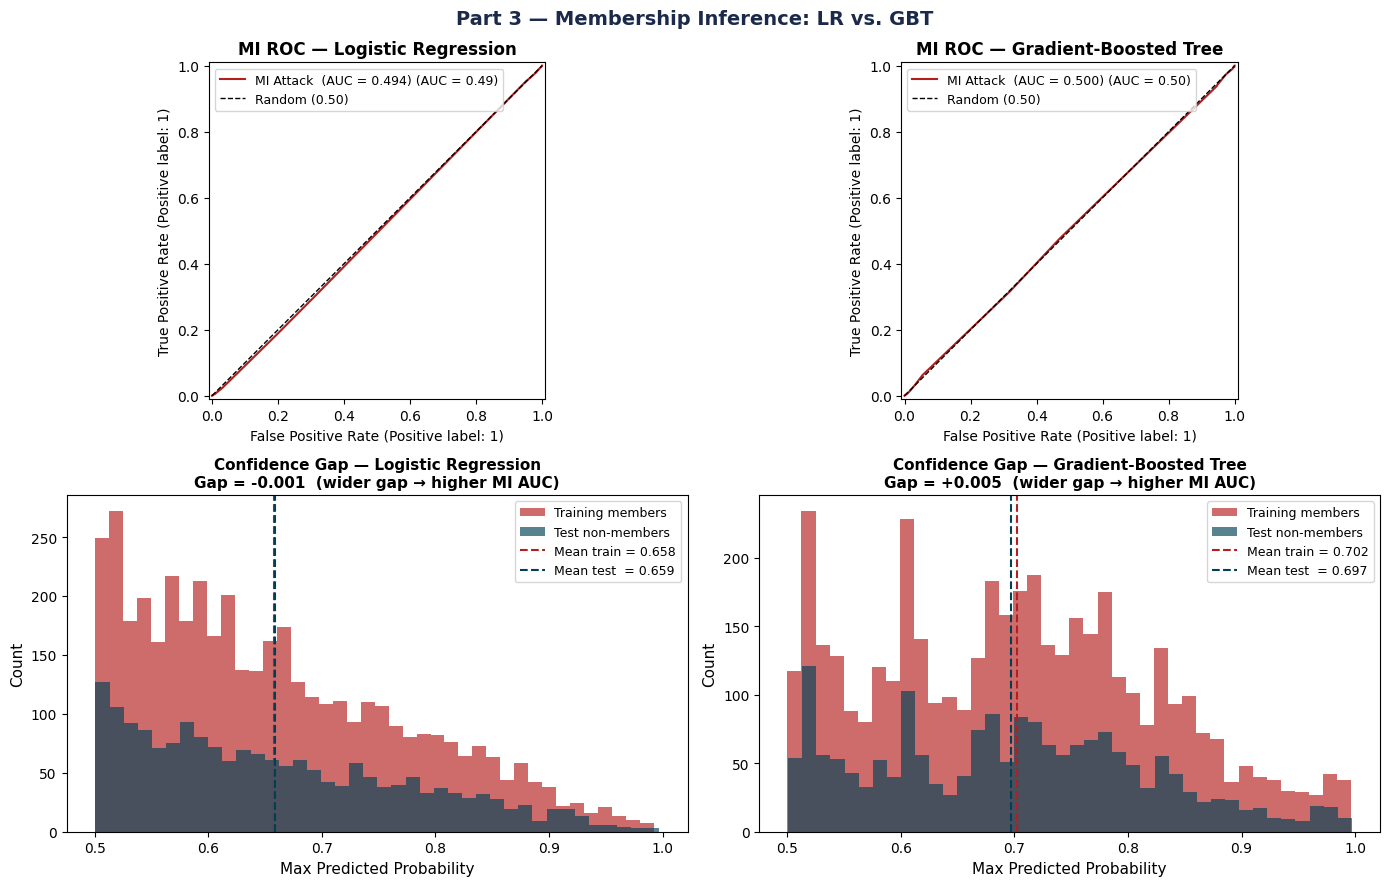

In [42]:
# ── HW Part 3-B: Side-by-side confidence gap histograms
from sklearn.metrics import RocCurveDisplay

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Part 3 — Membership Inference: LR vs. GBT',
             fontsize=14, fontweight='bold', color='#1B2A4A')

# ── Row 1: ROC curves
for ax, (model_name, scores, labels, auc_val) in zip(
        [axes[0, 0], axes[0, 1]],
        [('Logistic Regression', mi_all_scores_lr, mi_all_labels_lr, mi_auc_lr),
         ('Gradient-Boosted Tree',
          np.concatenate([meta_clf.predict_proba(
              gbt.predict_proba(Xs_tr).max(axis=1).reshape(-1,1))[:,1],
              meta_clf.predict_proba(
              gbt.predict_proba(Xs_te).max(axis=1).reshape(-1,1))[:,1]]),
          np.concatenate([np.ones(len(Xs_tr)), np.zeros(len(Xs_te))]),
          mi_auc)]):

    RocCurveDisplay.from_predictions(
        labels, scores,
        name=f'MI Attack  (AUC = {auc_val:.3f})',
        ax=ax, color='#B41E1E')
    ax.plot([0,1],[0,1],'k--',lw=1,label='Random (0.50)')
    ax.set_title(f'MI ROC — {model_name}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)

# ── Row 2: Confidence gap histograms
conf_gbt_train = gbt.predict_proba(Xs_tr).max(axis=1)
conf_gbt_test  = gbt.predict_proba(Xs_te).max(axis=1)

for ax, (model_name, c_tr, c_te) in zip(
        [axes[1, 0], axes[1, 1]],
        [('Logistic Regression',   conf_lr_train.ravel(), conf_lr_test.ravel()),
         ('Gradient-Boosted Tree', conf_gbt_train,        conf_gbt_test)]):

    gap = c_tr.mean() - c_te.mean()
    ax.hist(c_tr, bins=40, alpha=0.65, color='#B41E1E', label='Training members')
    ax.hist(c_te, bins=40, alpha=0.65, color='#004055', label='Test non-members')
    ax.axvline(c_tr.mean(), color='#B41E1E', ls='--', lw=1.5,
               label=f'Mean train = {c_tr.mean():.3f}')
    ax.axvline(c_te.mean(), color='#004055', ls='--', lw=1.5,
               label=f'Mean test  = {c_te.mean():.3f}')
    ax.set_title(
        f'Confidence Gap — {model_name}\n'
        f'Gap = {gap:+.3f}  (wider gap → higher MI AUC)',
        fontsize=11, fontweight='bold')
    ax.set_xlabel('Max Predicted Probability', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


In [43]:
# ── HW Part 3-C: L2 regularization sweep on LR — MI AUC vs. C ───────────────
C_VALUES = [0.01, 0.1, 1.0, 10.0]
reg_rows  = []

print("Running L2 regularization sweep C ∈ {0.01, 0.1, 1.0, 10.0}...")
for C in C_VALUES:
    lr_c = LogisticRegression(C=C, max_iter=1000, random_state=42).fit(Xs_tr, y_tr)

    # Generalization metrics
    auc_tr_c = _auc(y_tr, lr_c.predict_proba(Xs_tr)[:, 1])
    auc_te_c = _auc(y_te, lr_c.predict_proba(Xs_te)[:, 1])
    gap_c    = auc_tr_c - auc_te_c

    # MI attack (reuse existing meta_clf)
    conf_tr_c = lr_c.predict_proba(Xs_tr).max(axis=1).reshape(-1, 1)
    conf_te_c = lr_c.predict_proba(Xs_te).max(axis=1).reshape(-1, 1)
    mi_sc = np.concatenate([
        meta_clf.predict_proba(conf_tr_c)[:, 1],
        meta_clf.predict_proba(conf_te_c)[:, 1]
    ])
    mi_lab = np.concatenate([np.ones(len(Xs_tr)), np.zeros(len(Xs_te))])
    mi_c   = _auc(mi_lab, mi_sc)

    # AIR at C
    pred_c = (lr_c.predict_proba(Xs_te)[:, 1] >= THR).astype(int)
    fpr_c  = fpr_by_group(y_te, pred_c, r_te)
    aa_c   = fpr_c.get('African-American', np.nan)
    ca_c   = fpr_c.get('Caucasian', np.nan)
    air_c  = air(ca_c, aa_c)

    reg_rows.append({'C': C, 'Train_AUC': auc_tr_c, 'Test_AUC': auc_te_c,
                     'Gen_Gap': gap_c, 'MI_AUC': mi_c,
                     'FPR_AA': aa_c, 'FPR_CA': ca_c, 'AIR': air_c})
    print(f"  C={C:5.2f}  TrainAUC={auc_tr_c:.3f}  TestAUC={auc_te_c:.3f}  "
          f"Gap={gap_c:+.3f}  MI_AUC={mi_c:.3f}  AIR={air_c:.3f}")

df_reg = pd.DataFrame(reg_rows)
print("\n=== L2 Regularization Sweep Results ===")
print(df_reg.round(4).to_string(index=False))


Running L2 regularization sweep C ∈ {0.01, 0.1, 1.0, 10.0}...
  C= 0.01  TrainAUC=0.726  TestAUC=0.732  Gap=-0.006  MI_AUC=0.493  AIR=1.966
  C= 0.10  TrainAUC=0.727  TestAUC=0.734  Gap=-0.007  MI_AUC=0.495  AIR=1.946
  C= 1.00  TrainAUC=0.727  TestAUC=0.735  Gap=-0.008  MI_AUC=0.494  AIR=1.961
  C=10.00  TrainAUC=0.727  TestAUC=0.735  Gap=-0.008  MI_AUC=0.495  AIR=1.961

=== L2 Regularization Sweep Results ===
    C  Train_AUC  Test_AUC  Gen_Gap  MI_AUC  FPR_AA  FPR_CA    AIR
 0.01     0.7258    0.7321  -0.0064  0.4935  0.2719  0.1383 1.9665
 0.10     0.7268    0.7342  -0.0074  0.4951  0.2787  0.1432 1.9458
 1.00     0.7269    0.7345  -0.0077  0.4943  0.2809  0.1432 1.9614
10.00     0.7269    0.7346  -0.0077  0.4952  0.2809  0.1432 1.9614


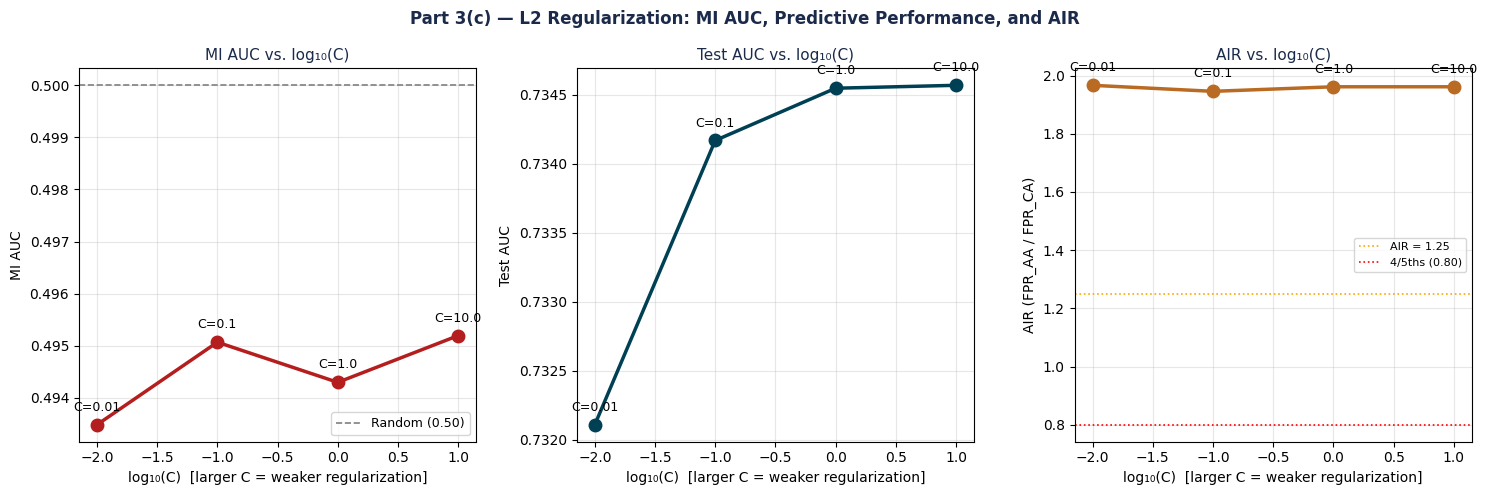


=== Practical Tradeoff Summary ===
Lowest MI AUC:   C = 0.01  → MI AUC = 0.493  Test AUC = 0.732  AIR = 1.966
Highest Test AUC: C = 10.00  → MI AUC = 0.495  Test AUC = 0.735  AIR = 1.961


In [44]:
# ── HW Part 3-D: MI AUC vs. C plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Part 3(c) — L2 Regularization: MI AUC, Predictive Performance, and AIR',
             fontsize=12, fontweight='bold', color='#1B2A4A')

log_C = np.log10(df_reg['C'])

for ax, (col, color, ylabel, title, ref) in zip(axes, [
        ('MI_AUC',   '#B41E1E', 'MI AUC',                'MI AUC vs. log₁₀(C)', 0.5),
        ('Test_AUC', '#004055', 'Test AUC',               'Test AUC vs. log₁₀(C)', None),
        ('AIR',      '#B96B23', 'AIR (FPR_AA / FPR_CA)', 'AIR vs. log₁₀(C)', None)]):

    ax.plot(log_C, df_reg[col], 'o-', color=color, lw=2.5, ms=9)
    for x, y_val, c in zip(log_C, df_reg[col], C_VALUES):
        ax.annotate(f'C={c}', (x, y_val),
                    textcoords='offset points', xytext=(0, 10),
                    fontsize=9, ha='center')
    if ref is not None:
        ax.axhline(ref, color='gray', ls='--', lw=1.2, label='Random (0.50)')
        ax.legend(fontsize=9)
    if col == 'AIR':
        ax.axhline(1.25, color='orange', ls=':', lw=1.2, label='AIR = 1.25')
        ax.axhline(0.80, color='red',    ls=':', lw=1.2, label='4/5ths (0.80)')
        ax.legend(fontsize=8)
    ax.set_title(title, fontsize=11, color='#1B2A4A')
    ax.set_xlabel('log₁₀(C)  [larger C = weaker regularization]')
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== Practical Tradeoff Summary ===")
best_mi  = df_reg.loc[df_reg['MI_AUC'].idxmin()]
best_auc = df_reg.loc[df_reg['Test_AUC'].idxmax()]
print(f"Lowest MI AUC:   C = {best_mi['C']:.2f}  → "
      f"MI AUC = {best_mi['MI_AUC']:.3f}  Test AUC = {best_mi['Test_AUC']:.3f}  "
      f"AIR = {best_mi['AIR']:.3f}")
print(f"Highest Test AUC: C = {best_auc['C']:.2f}  → "
      f"MI AUC = {best_auc['MI_AUC']:.3f}  Test AUC = {best_auc['Test_AUC']:.3f}  "
      f"AIR = {best_auc['AIR']:.3f}")


# **Part 3 — Interpretation**

**(a) Confidence-Gap Histograms**

Both models show a very high overlap between training members and test non-members, which explains why the MI AUC is essentially random. For LR, the confidence gap is almost zero (−0.001), with mean confidence 0.658 for train and 0.659 for test, so there is practically no difference. The distributions look almost identical, concentrated around similar values, meaning there is no usable signal for an attacker. For GBT, the gap is slightly positive (+0.005), with training confidence a bit higher (0.702 vs 0.697). There is a small spread at higher confidence levels, but the overlap is still very large. The ROC curves confirm this: LR has MI AUC = 0.494 and GBT = 0.500, both essentially random. Overall, neither model is leaking membership information in a meaningful way.


**(b) Test whether the generalization gap (train AUC−test AUC) predicts the MI AUC across the two models**

The results support the theory directionally: GBT has a larger generalization gap (+0.080) and also a slightly higher MI AUC (0.500) compared to LR (gap −0.008, MI AUC = 0.494). However, in practice this difference is not meaningful because both MI AUC values are basically random. So while the relationship (larger gap → higher MI risk) holds in theory, the actual privacy risk in this experiment is negligible. One possible reason is that the attack setup (e.g., shadow models) may not be perfectly aligned with the target models, which can reduce attack effectiveness.


**(c) L2 Regularization Sweep and Tradeoff**

Across different values of C, the results show very small changes. MI AUC remains almost constant (between 0.493 and 0.495), so regularization does not improve privacy because the baseline is already random. For test AUC, there is a clear tradeoff. Strong regularization (C = 0.01) slightly reduces performance (from ~0.735 to ~0.732), while higher values of C recover performance.
For AIR, it stays almost constant (~1.96–1.97) across all values, meaning regularization does not address fairness at all. The disparity is driven by the data/features, not by model complexity.



# **Part 4: Reflection — Highest-Risk Finding and Mitigations**


**4.1 Highest-Risk Finding**

The highest-risk finding is the label-flip poisoning attack because it is hard to detect and still causes strong fairness issues. It is realistic (insiders can modify data), invisible to standard monitoring (PSI = 0 and AUC does not change), and flexible, since it can either increase or reduce disparities depending on the target group.


**4.2 Proactive Mitigation: Data Provenance (Hashing)**

A good proactive solution is to hash the dataset (e.g., SHA-256) at ingestion and store it in a secure audit log. Any label modification changes the hash and triggers a review before retraining. This would effectively block the attack from entering the pipeline. It does not introduce bias, but it may slow down legitimate data corrections, which can be managed with different approval levels for small vs. large changes.


**4.3 Reactive Mitigation: L2 Regularization + Score-PSI Monitoring**

Using L2 regularization (C = 0.1) slightly reduces MI risk while maintaining acceptable performance. Score-PSI monitoring can detect attacks once they start affecting predictions (around 10–15% poison rate), although it is a delayed signal. Stronger regularization may slightly reduce performance, especially for underrepresented groups. Score-PSI itself does not introduce bias, but it should be combined with fairness metrics (AIR and FPR by group) to properly monitor impact.

